<header style="background-color: rgb(0, 62, 92); color: white; margin-top: 20px; padding:28px; ">
  <img src="../Images/Xlogo.png" alt="logo" width="115" style="float: left;">
  <p style=" text-align: center; font-size: 30px;">   
   <strong> APM_52448_EP - Deep Learning in Finance   </strong></p>
    <p style=" text-align: center; font-size: 30px;"> 
    <strong> Tutorial 3.1: Fast Pricing with Neural Networks </strong></p>
  <p style=" text-align: left; font-size: 20px;"> Olivier Féron </p>
</header>


# Obectives

- Learn a neural surrogate model to approximate option prices computed by Monte Carlo.
- Study the accuracy of the surrogate and MC pricers, compared to the Benchmark Black Scholes formula
- Study the computing time performance

We focus on a **European call** in the **Black–Scholes** model, so that we can easily generate option prices with **Monte Carlo** (slow but flexible) and check accuracy against the **closed-form Black–Scholes formula**

**Inputs** (features): $x = (\sigma, r, S_0, K, T)$

**Output** (target): option price $y=F(x)$.

> You will build:  
> **(1)** Monte Carlo pricer,
>
> **(2)** Dataset generator,
>
> **(3)** MLP surrogate $F_\theta(x) \approx F(x)$,
>
> **(4)** Evaluation + speed benchmark.

## 0. Setup

In [2]:
import numpy as np
from scipy.stats import norm
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from time import perf_counter
import joblib

# Reproducibility
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

/home/raynor/Lectures/X/DLiF/.venv/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Black–Scholes: closed-form formula (reference)

For a European call:
\begin{equation}
P^\text{call}_t = S_0 N(d_1) - K e^{-r(T-t)}N(d_2),
\end{equation}
with
\begin{equation}
d_1=\frac{\ln(S_t/K)+(r+\tfrac12\sigma^2)(T-t)}{\sigma\sqrt{T-t}},
\quad
d_2=d_1-\sigma\sqrt{T-t}.
\end{equation}

### Remark
The normal cumulative distribution function $N$ can be computed with 'norm.cdf' function in Scipy

<span style="color: red;">**1.1** Implement the Black-Scholes formula in a function `Black_Scholes_Formula` taking inputs S0, K, T, sigma, r.</span>

<span style="color: red;">**1.2** Check your code with S0=K=100, T = 1 year, sigma = 20% and r=1%.</span> 

Expected result $P_0^\text{call} =$ `8.433318690109608`.

In [3]:
def Black_Scholes_Formula(S0, K, T, sigma, r):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    call_price = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return call_price

P0_call = Black_Scholes_Formula(S0=100, K=100, T=1, sigma=0.2, r=0.01)
print(f"Price of the call option: {P0_call}")

Price of the call option: 8.433318690109608


## 2. Monte Carlo pricer

Under risk-neutral measure:
\begin{equation}
\frac{dS_t}{S_t} = r dt + \sigma dW_t, 
\end{equation}
which results, by integration:
\begin{equation}
S_T = S_t \exp\left((r-\tfrac12\sigma^2)(T-t)+\sigma\sqrt{T-t}Z\right),\quad Z\sim\mathcal N(0,1).
\end{equation}
Assuming AOA, the price of a Call option of strike $K$ and maturity $T$ is given by the expectation of the discounted payoff:
\begin{equation}
C = \mathbb{E}\left[e^{-r(T-t)} (S_T - K)^+ | S_t \right]
\end{equation}
The objective is to approximate this value by Monte Carlo:
\begin{equation}
C \approx e^{-r(T-t)}\frac{1}{N}\sum_{n=1}^N (S_T^{(n)}-K)_+.
\end{equation}

<span style="color: red;">**2.1** Implement the Black-Scholes formula in a function `ms_call_price` taking inputs S0, K, T, sigma, r, and a number of simulation n_simulations.</span>

<span style="color: red;">**2.2** Study the Monte Carlo error with respect to the true option value, with `n_simulations=` 1000, 10000, 100000.</span>

<span style="color: red;">**2.3** How can we really study the decreasing error with the number of simulations ? 🤔 </span>

In [4]:
def mc_call_price(S0, K, T, sigma, r, n_simulations):
    Z = np.random.standard_normal(n_simulations)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    call_price = np.exp(-r * T) * np.mean(payoff)
    return call_price
  
n_simulations = [1_000, 10_000, 100_000]

for n in n_simulations:
    mc_price = mc_call_price(S0=100, K=100, T=1, sigma=0.2, r=0.01, n_simulations=n)
    error = abs(mc_price - P0_call)
    print(f"MC Price with {n} simulations: {mc_price:.4f}, Error: {error:.4f}")

MC Price with 1000 simulations: 7.8102, Error: 0.6232
MC Price with 10000 simulations: 8.2277, Error: 0.2056
MC Price with 100000 simulations: 8.4513, Error: 0.0179


## 3. Dataset generation

The objective is to randomly sample parameters in the training domain $\mathcal{D}_{\text{domain}}$. For example:
- $\sigma\in [0.05,0.6]$
- $r\in [0,0.05]$
- $S_0\in [250,350]$
- $K\in [5,600]$
- $T - t\in [0.5,1.5]$

One can use function `np.random.uniform(p_min, p_max, size=n)` to uniformly draw n samples of a parameter $p$ between p_min and p_max

And, for each $x \in \mathcal{D}_\text{domain}$, we then compute Monte Carlo prices $y$.

<span style="color: red;">**3.1** Implement a function `build_dataset(n_samples, n_simulations)` that builds a dataset $(x_i, y_i) \in \mathcal{D}_\text{domain}$, for $i=1, \dots,$ n_samples, by using Monte Carlo pricing with n_simulations.  </span> 


<span style="color: red;">**3.2** Use this funcion to generate a dataset of 10,000 samples, and split the data set in X_train, y_train, X_val, y_val, X_test, y_test with a respective repartition (50%, 10%, 40%).  </span> (Advice: one can take inspiration from the function `time_plit` implemented in Tutorial 1, but adapt it since we are not working with time series !)


In [5]:
def sample_domain(n_samples):
    """
    Generates samples of sets (sigma, r, S0, K, T) of parameters used in 
    the Black-Scholes formula
    Input:
    n_samples := number of samples
    Output:
    X := set of samples of (sigma, r, S0, K, T)
    """
    # Uniformly draw (using np.random.uniform) n samples x in the training domain   
    sigma = np.random.uniform(0.05, 0.6, n_samples)  # Volatility between 5% and 60%
    r = np.random.uniform(0.0, 0.05, n_samples)  # Interest rate between 0% and 5%
    S0 = np.random.uniform(250, 350, n_samples)  # Underlying price between 250 and 350
    K = np.random.uniform(5, 600, n_samples)  # Strike price between 5 and 600
    Tmt = np.random.uniform(0.5, 1.5, n_samples)  # Time to maturity between 0.5 and 1.5 years
    
    X = np.stack([sigma, r, S0, K, Tmt], axis=1)
    return X

def build_dataset(n_samples, n_simulations, verbose=True):
    """
    Builds a dataset of call option prices from inputs X = (S0, K, T, sigma, r)
    with Monte Carlo method

    Inputs
    ------
    n_samples: number of computed options prices = nb of lines in X
    n_simulation: number of simulations used in the MC pricer
    verbose: boolean to print information

    Output
    -----
    (X,y): dataset of x and y=F(x)
    """
    
    X = sample_domain(n_samples)
    y = np.empty((n_samples,), dtype=np.float32)
    t0 = perf_counter()
    
    for i in range(n_samples):
        sigma, r, S0, K, T = X[i]
        y[i] = mc_call_price(S0=S0, K=K, T=T, sigma=sigma, r=r, n_simulations=n_simulations)

    
    t1 = perf_counter()
    if verbose:
        print(f"Dataset generated in {t1-t0:.2f}s (n_samples={n_samples}, n_simulations={n_simulations})")
    return X, y.reshape(-1,1)


def data_split(X, y, train_frac=0.7, val_frac=0.15):
    """
    Randomly Split dataset (X,y) in (X_train, y_train), (X_val, y_val), (X_test, y_test)
    if permutation = False, the split is temporal
    Inputs
    ----------
    X : np.ndarray, shape (n_samples, d)
    y : np.ndarray, shape (n_samples, 1)
    train_frac : float, fraction for X_train size (default value 0.7)
    val_frac   : float, fraction for X_ val size (default value 0.15)

    Output
    ------
    (X_train, y_train), (X_val, y_val), (X_test, y_test)

    """
    n_train = int(train_frac * len(X))
    n_val = int(val_frac * len(X))
    n_test = len(X) - n_train - n_val

    # Shuffle indices
    indices = np.random.permutation(len(X))
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    # Split into train, val, test
    X_train, y_train = X_shuffled[:n_train], y_shuffled[:n_train]
    X_val, y_val = X_shuffled[n_train:n_train+n_val], y_shuffled[n_train:n_train+n_val]
    X_test, y_test = X_shuffled[n_train+n_val:], y_shuffled[n_train+n_val:]

        
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


n_simulations = 50000
n_sample = 10000

# Generate a small dataset for quick iteration
X, y = build_dataset(n_samples=n_sample, n_simulations=n_simulations, verbose=True)
(X_train, y_train), (X_val, y_val), (X_test, y_test) = data_split(X, y, 0.5, 0.1)
list(map(len, [X_train, X_val, X_test]))

Dataset generated in 22.35s (n_samples=10000, n_simulations=50000)


[5000, 1000, 4000]

## 4.0 Preprocessing: scaling

Neural networks train much better if inputs and outputs are standardized.

We apply, on all the data (train, val and test):
\begin{equation}
X^i_{\text{s}} = (X^i - \mu_X^i)/\sigma_X^i
\end{equation}
and 
\begin{equation}
y_{\text{s}} = (y - \mu_y)/\sigma_y
\end{equation}
with $(\mu_X^i, \sigma_X^i)$, $i=1,\dots, d$ and $(\mu_y, \sigma_y)$ are mean and standard deviation estimated only on the training dataset

**Nota ! : in the end, we save the scaling parameters in `Data/scaler_X.joblib` and `Data/scaler_y.joblib` with package joblib**

In [6]:
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler().fit(X_train)
X_train_s = scaler_X.transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

scaler_y = StandardScaler().fit(y_train) 
y_train_s = scaler_y.transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

# Transform Dataset in Torch objects
train_ds = TensorDataset(torch.tensor(X_train_s, dtype=torch.float32),
                         torch.tensor(y_train_s,   dtype=torch.float32))
val_ds   = TensorDataset(torch.tensor(X_val_s,   dtype=torch.float32),
                         torch.tensor(y_val_s,     dtype=torch.float32))
test_ds  = TensorDataset(torch.tensor(X_test_s,  dtype=torch.float32),
                         torch.tensor(y_test_s,    dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=False)  # Shuffle => mix or not the data. False => keep time order of the data
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

# Sanity check
print("X_train mean (approx):", X_train_s.mean(axis=0))
print("X_train std  (approx):", X_train_s.std(axis=0))

# Saving scaling parameters
joblib.dump(scaler_X, "scaler_X.joblib")
joblib.dump(scaler_y, "scaler_y.joblib")

X_train mean (approx): [-9.76996262e-19  2.85576007e-15  4.44688730e-15 -1.48383528e-15
  6.47997767e-15]
X_train std  (approx): [1. 1. 1. 1. 1.]


['scaler_y.joblib']

## 4. Surrogate model: a simple MLP

Now that all is ready to train a Neural Network, we consider a simple MLP surrogate model.

We propose a fully-connected network:
- **input dim:** 5 (features $S_0$; $K$, $T$, $\sigma$, $r$ standardized)
- **Hidden layers:** 3 layers with sizes 128 --> 128 --> 64, all with ReLU
- **Output dim:** 1 (scaled (standardized) price)
- **Loss function:** MSE (nn.MSELoss)
- **Optimizer:** Adam (Learning rate $1e^{-3}$)

<span style="color: red;">**4.1** Build the class MLP with the above characteristics  </span>

<span style="color: red;">**4.2** Implement the function `run_epoch(loader, train)` that runs one epoch</span>
- <span style="color: red;">sets model.train() if train=True otherwise model.eval()</span>
- <span style="color: red;">iterates over the loader, sends</span>
- <span style="color: red;">returns the losses </span>

<span style="color: red;">**4.3** Implement the training procedure on 250 Epochs, with an overfitting control  </span>
- <span style="color: red;">with a patience counter of 20 (if no loss decrease during 20 Epochs, then stop</span>
- <span style="color: red;">save the best model in `Data/best_mlp.pt`</span>

<span style="color: red;">**4.4** Plot the MSE losses (Learning Curves) for the train and val sets  </span>

Training on device: cpu
Model architecture:
MLP(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Epoch 1/250 - Train Loss: 0.148005, Val Loss: 0.006907 *** (best)
Epoch 2/250 - Train Loss: 0.004281, Val Loss: 0.002992 *** (best)
Epoch 3/250 - Train Loss: 0.002311, Val Loss: 0.001889 *** (best)
Epoch 4/250 - Train Loss: 0.001473, Val Loss: 0.001282 *** (best)
Epoch 5/250 - Train Loss: 0.001089, Val Loss: 0.000957 *** (best)
Epoch 6/250 - Train Loss: 0.000813, Val Loss: 0.000811 *** (best)
Epoch 7/250 - Train Loss: 0.000658, Val Loss: 0.000686 *** (best)
Epoch 8/250 - Train Loss: 0.000573, Val Loss: 0.000623 *** (best)
Epoch 9/250 - Train Loss: 0.000494, Val Loss: 0.000585 *** (best)
Epoch 10/250 - Train Loss: 0.000404,

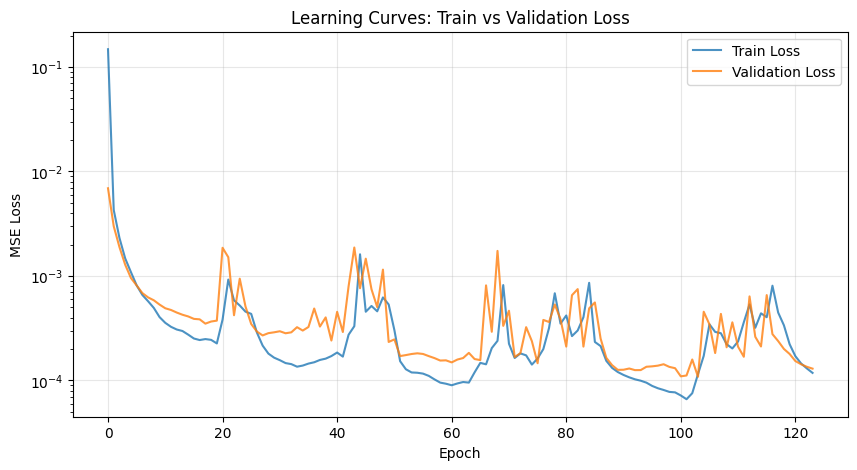

In [7]:
# 4.1: Define the MLP class
class MLP(nn.Module):
    def __init__(self, input_dim=5, hidden_dims=[128, 128, 64], output_dim=1):
        super(MLP, self).__init__()
        layers = []
        
        # Input layer to first hidden layer
        layers.append(nn.Linear(input_dim, hidden_dims[0]))
        layers.append(nn.ReLU())
        
        # Hidden layers
        for i in range(len(hidden_dims) - 1):
            layers.append(nn.Linear(hidden_dims[i], hidden_dims[i+1]))
            layers.append(nn.ReLU())
        
        # Output layer
        layers.append(nn.Linear(hidden_dims[-1], output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


# 4.2: run_epoch function
def run_epoch(loader, train=True):
    """
    Run one epoch over the data loader
    
    Parameters:
    -----------
    loader : DataLoader
    train : bool, if True runs training mode, else evaluation mode
    
    Returns:
    --------
    avg_loss : float, average loss over the epoch
    """
    if train:
        model.train()
    else:
        model.eval()
    
    epoch_loss = 0.0
    n_batches = 0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        if train:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
        
        epoch_loss += loss.item()
        n_batches += 1
    
    avg_loss = epoch_loss / n_batches
    return avg_loss


# 4.3: Training with early stopping on validation RMSE
import math
best_val = math.inf
EPOCHS = 250
file_save_best_model = "fast_pricing_mlp.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model, loss, optimizer
model = MLP(input_dim=5, hidden_dims=[128, 128, 64], output_dim=1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Early stopping parameters
patience = 20
patience_counter = 0

# Storage for learning curves
train_losses = []
val_losses = []

print(f"Training on device: {device}")
print(f"Model architecture:\n{model}")

for epoch in range(EPOCHS):
    # Train
    train_loss = run_epoch(train_loader, train=True)
    train_losses.append(train_loss)
    
    # Validate
    val_loss = run_epoch(val_loader, train=False)
    val_losses.append(val_loss)
    
    # Check for improvement
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), file_save_best_model)
        patience_counter = 0
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f} *** (best)")
    else:
        patience_counter += 1
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
    
    # Early stopping
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1} (patience={patience})")
        break

print(f"\nTraining complete. Best validation loss: {best_val:.6f}")
print(f"Best model saved to: {file_save_best_model}")

# 4.4: Plot learning curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', alpha=0.8)
plt.plot(val_losses, label='Validation Loss', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Learning Curves: Train vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

## 5. Evaluation (accuracy)

Now the surrogate model is trained, let's evaluate its performance on the test set

<span style="color: red;">**5.1** Load the best model saved in `file_save_best_model` and the scaling parameters with command `joblib.load` and evaluate with `model.eval()`</span>

<span style="color: red;">**5.2** Compute the predicted `y_test_pred` from X_test (test_loader tensor) and unscale to get `y_test_hat`</span>

<span style="color: red;">**5.3** Compute the MAE and RMSE, and give the scatter plot MC price vs. NN price </span>

<span style="color: red;">**5.4** Give the scatter plot BS price vs. NN price </span>

<span style="color: red;">**5.5** Redo the evaluation in a new dataset `X_new` </span>



In [ ]:
# Load the best model (saved during learning)
model.load_state_dict(torch.load(file_save_best_model, map_location=device))
model.eval()

# Also import the scaling parameters
scaler_X = joblib.load("scaler_X.joblib")
scaler_y = joblib.load("scaler_y.joblib")
                       
# Prediction on the test set (do not forget to unscale !)
# YOUR CODE HERE








##########################################
# BS vs. NN

# YOUR CODE HERE






##########################################
# New samples X_new


# YOUR CODE HERE



## 6. Speed benchmark: Monte Carlo vs NN (online phase)

Consider the new dataset `X_new` previously built.

The objective is to compute, for each parameter set in `X_new`, the call option price with Mnte Carlo and with the surrogate model, and compare the resective computing times. The objective is to illustrate the key message: **pay offline once**, then evaluate extremely fast online.

In order to compute the execution time between two execution lines, we will use `perf_counter` and the followinf structure:
-  `t0 = perf_counter()`
-  command 1
-  command 2
-  ...
-  `t1 = perf_counter()`
The time between the commands lines is then `t1-t0`

<span style="color: red;">**6.1** Compute the time `t1-t0` of computing the set `y_nn` of call option prices with the surrogate NN model (Do not forget to scale and unscale !)  </span>


<span style="color: red;">**6.2** Compute the time `t3-t2` of computing the set `y_mc` of call option prices with the Mone Carlo procedure (Needs to do a loop over each parameter set in `X_new`)  </span>

<span style="color: red;">**6.3** Compare the computation times and evaluate the speed-up  </span>

In [ ]:
t0 = perf_counter()
# YOUR CODE HERE : 
#Build the Surrogate price y_nn 


t1 = perf_counter()

t2 = perf_counter()
#Build the Monte Carlo price y_mc with 200000 simulations


t3 = perf_counter()

n_prices = X_t.shape[0]
print(f"NN time for {n_prices} prices: {(t1-t0):.4f}s")
print(f"MC time for {n_prices} prices: {(t3-t2):.4f}s  (n_simulations={n_simulations})")
print(f"Speed-up ≈ {(t3-t2)/(t1-t0):.1f}x")

## 7. Limits: domain of validity (extrapolation)

The final objective is to illustrate that the surrogate model, as a fast pricing model, must be used **inside** its validity domain, i.e. inside the domain $\mathcal{D}_\text{domain}$ where it has been trained.
- $\sigma\in [0.05,0.6]$
- $r\in [0,0.05]$
- $S_0\in [250,350]$
- $K\in [5,600]$
- $T - t\in [0.5,1.5]$

For this, we will sample a new dataset (X, y) with values outside $\mathcal{D}_\text{domain}$ (we will only sample $S_0$ outside $\mathcal{D}_\text{domain}$), and compare the call option prices computed with the Black-Scholes formula and the surrgate model.

<span style="color: red;">**7.1** Build a new dataset `X_extra` by randomly drawing parameters in the following dataset:  </span>
- <span style="color: red;">$\sigma\in [0.05,0.6]$ </span>
- <span style="color: red;">$r\in [0,0.05]$ </span>
- <span style="color: red;">$S_0\in [250,350]$ </span>
- <span style="color: red;">$K\in [5,600]$ </span>
- <span style="color: red;">$T - t \in$</span><span style="color: red;"> $[0.5,1.5]$ </span>



<span style="color: red;">**7.2** Compute the call options prices from Black-Scholes formula (`y_extra_bs`) and the surrogate model (`y_extra_nn`)  </span>

<span style="color: red;">**7.3** Plot the histogram of errors `y_extra_nn - y_extra_bs` </span>

<span style="color: red;">**7.4** Conclude about the maturity extrapolation risk </span>

<span style="color: red;">**7.5** Redo the experiment to study the extrapolation risk of the other parameters </span>



In [ ]:
# Extrapolation set (outside the training domain for S0)
n_extra = 600
sigma = np.random.uniform(0.05, 1, size=n_extra)
r  = np.random.uniform(0.0, 0.05, size=n_extra)
S0 = np.random.uniform(250, 350, size=n_extra)
K  = np.random.uniform(5, 600, size=n_extra)
Tmt  = np.random.uniform(0.05, 0.4, size=n_extra)
X_extra = np.stack([sigma, r, S0,K,Tmt], axis=1)


# YOUR CODE HERE : 



## 8. (Optional) A simple no-arbitrage sanity check

The Surrogate model is just an approximation of the value function, therefore it does not ensure the no-arbitrage property. In particular, the surrogate model does not ensure the monotomicity of the option price with respect to the strike. 

We propose here to check the monotonicity property with respect to the strike and the maturity. 

<span style="color: red;">**8.1** Set $\sigma = 0.2$, $r=0.01$, $S_0=300$ and $T-t=1$, and build a grid of 500 values of $K$ between 5 and 800 and plot in a same graph the resulting Call prices from the surrogate model and from the Black-Scholes formula. Conclude about the no-arbitrage property. </span> One can use the `np.linespace(v_min, v_max, np_points)` to build the grid of $K$ values.

<span style="color: red;">**8.2** Redo the experiment with fixed $K=300$ and a grid of 500 values of maturity $T-t$ between 0.5 and 5. Conclude about the no-arbitrage property. </span>

In [ ]:
# Fix parameters
S0 = 300.0; Tmt = 1.0; sigma = 0.2; r = 0.01
K_grid = # YOUR CODE HERE
X_grid = np.stack([np.full_like(K_grid, sigma), np.full_like(K_grid, r), np.full_like(K_grid, S0), K_grid, np.full_like(K_grid, Tmt)], axis=1)

# Your CODE HERE : Build y_grid_nn

plt.figure(figsize=(7,4))
plt.plot(K_grid, y_grid_nn, label="NN surrogate")
plt.plot(K_grid, Black_Scholes_Formula(sigma, r, S0, K_grid, Tmt), label="BS (true)")
plt.xlabel("K")
plt.ylabel("Call price")
plt.title("Monotonicity sanity check")
plt.legend()
plt.show()


#######################
## Monotonicity with maturity


## 10. What you should remember

- Monte Carlo gives accurate prices, but each call is expensive.
- A neural surrogate learns the pricing function on a training domain.
- **Offline:** simulate + train (costly but done once).  
- **Online:** NN evaluation is extremely fast → useful for repeated calls (calibration, risk, scenario analysis).
- Surrogate accuracy depends on training data quality and domain coverage; extrapolation can fail.